# 03 · Advanced

This notebook covers six topics: fragments, conditionals, custom waveforms and sweep sources, vendor extensions, platform implementations, and capability validation. Each section defines its own programs and example parameters, so you can run the sections independently after running the two setup cells below.

You will learn how to reuse pulse sequences, branch on measurement outcomes, extend the language, and describe what a platform supports. The final section shows how to inspect execution plans and apply a program transformation.

The examples use plain string bus names until section 3.5 introduces a schema. Simulation uses the reference platform; the vendor extensions demonstrate language and capability support without connecting to instruments.

In [1]:
# Install missing tutorial dependencies. Check availability without importing vendor
# modules so section 3.4 can demonstrate automatic extension loading.
from importlib.util import find_spec

if (
    find_spec("qprogram") is None
    or find_spec("qprogram_qblox") is None
    or find_spec("qprogram_qdac") is None
):
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable, "-m", "pip", "install",
            "qprogram[viz]==0.2.0", "qprogram-qblox==0.2.0", "qprogram-qdac==0.2.0",
        ],
        check=True,
    )

from importlib.metadata import version

print("qprogram", version("qprogram"))
print("qprogram-qblox", version("qprogram-qblox"))
print("qprogram-qdac", version("qprogram-qdac"))

qprogram 0.2.0
qprogram-qblox 0.2.0
qprogram-qdac 0.2.0


In [2]:
import sys
import warnings
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import qprogram as qp
import xarray as xr
from qprogram import MeasurementField
from qprogram.buses import BusSchema
from qprogram.plotting import Quantity, Style
from qprogram.waveforms import IQDrag, IQPair, Square

## 3.1 Fragments

A `Fragment` is a named, parameterised sequence that you can reuse across programs. Define the sequence once, then add calls to it with `qprogram.call`.

Use `@qp.fragment` to create a fragment from a Python function. Its first argument receives the fragment being built. The remaining arguments become fragment parameters in declaration order. The decorator accepts positional parameters without defaults; default values, `*args`, and keyword-only arguments are rejected when the fragment is defined.

In [3]:
@qp.fragment
def x_pulse(f, drive, amp):
    """Add a drive pulse to the fragment received as `f`."""
    f.play(drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))


qprogram = qp.QProgram(label="one_call")
qprogram.call(x_pulse, "q0/drive", 0.5)  # Pass both parameters positionally.
qprogram.call(x_pulse, "q0/drive", amp=0.5 / 2)  # Pass the amplitude by keyword.

print(qp.dumps(qprogram))

#!QProgram 0.2

metadata:
  label: "one_call"

fragment x_pulse(drive, amp):
  play drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)

body:
  x_pulse("q0/drive", 0.5)
  x_pulse("q0/drive", 0.25)



The `.qp` output contains a separate `fragment` definition and one statement for each call. This preserves the relationship between the reusable sequence and the programs that use it.

Fragment parameters can represent numbers, buses, or waveforms. Their values are supplied at each call. Inside the definition, arithmetic such as `2 * amp` creates an expression using the parameter. Arithmetic on ordinary Python values is evaluated before the call: in the second example above, `0.5 / 2` becomes `0.25`.

The next two cells demonstrate function signatures that the decorator does not support.

In [4]:
# Fragment parameters cannot have defaults.
try:
    @qp.fragment
    def with_default(f, drive, amp=0.5):
        pass
except qp.ValidationError as exc:
    print(exc)

@fragment 'with_default': parameter 'amp' has a default value; defaults are not supported


In [5]:
# The decorator needs a fixed parameter list, so *args is not supported.
try:
    @qp.fragment
    def with_star_args(f, *args):
        pass
except qp.ValidationError as exc:
    print(exc)

@fragment 'with_star_args': parameter 'args' is variadic positional; only plain positional parameters are supported


### Definition time and execution time

The decorator executes the Python function once to build the fragment. Calling the fragment later adds a call node; it does not run that Python function again.

Ordinary Python loops inside the function therefore determine the recorded structure at definition time. Below, `N_PULSES` sets the number of wait-and-play pairs recorded in `pulse_train`. The `spacing` parameter supplies the wait duration separately for each call.

In [6]:
N_PULSES = 3  # Number of wait-and-play pairs recorded when the fragment is defined.


@qp.fragment
def pulse_train(f, drive, spacing):
    """Wait for `spacing` nanoseconds before each pulse in the train."""
    for _ in range(N_PULSES):
        f.wait(drive, spacing)
        f.play(drive, "pi")


qprogram = qp.QProgram(label="two_calls")
qprogram.call(pulse_train, "q0/drive", 100)
qprogram.call(pulse_train, "q0/drive", 200)

# The fragment definition contains three wait/play pairs; the body contains two calls.
print(qp.dumps(qprogram))

#!QProgram 0.2

metadata:
  label: "two_calls"

fragment pulse_train(drive, spacing):
  wait drive spacing
  play drive "pi"
  wait drive spacing
  play drive "pi"
  wait drive spacing
  play drive "pi"

body:
  pulse_train("q0/drive", 100)
  pulse_train("q0/drive", 200)



### Expanding fragment calls

`expand()` returns a new program in which each fragment call becomes a block containing the fragment's operations, with the supplied arguments substituted for its parameters.

The two calls below produce two sets of three wait-and-play pairs: the first uses a spacing of 100 ns, and the second uses 200 ns.

Validation and execution expand fragment calls automatically. You can expand them explicitly to inspect the resulting operations.

In [7]:
print(qp.dumps(qprogram.expand()))

#!QProgram 0.2

metadata:
  label: "two_calls"

body:
  block:
    wait "q0/drive" 100
    play "q0/drive" "pi"
    wait "q0/drive" 100
    play "q0/drive" "pi"
    wait "q0/drive" 100
    play "q0/drive" "pi"
  block:
    wait "q0/drive" 200
    play "q0/drive" "pi"
    wait "q0/drive" 200
    play "q0/drive" "pi"
    wait "q0/drive" 200
    play "q0/drive" "pi"



### Binding waveforms

`with_waveforms` does not resolve aliases inside fragment calls. Expand the program first, then bind the aliases with `qprogram.expand().with_waveforms(library)`.

The library below defines the waveforms used by these examples. `PULSE_NS` is the duration of the `"pi"` waveform in nanoseconds. The measurement model later uses the same constant to calculate the total sequence duration.

In [8]:
PULSE_NS = 40  # ns; pulse duration used by both the waveform and the decay model.
READOUT_NS = 2000  # ns; shared duration for the probe waveform and its integration weights.

library = {
    "pi": IQDrag(amplitude=0.5, duration=PULSE_NS, sigma=10, beta=0.1),
    "probe": IQPair(
        I=Square(amplitude=1.0, duration=READOUT_NS),
        Q=Square(amplitude=0.0, duration=READOUT_NS),
    ),
    "weights": IQPair(
        I=Square(amplitude=1.0, duration=READOUT_NS),
        Q=Square(amplitude=1.0, duration=READOUT_NS),
    ),
}

# Binding does not reach the "pi" alias inside the fragment definition.
print(qp.dumps(qprogram.with_waveforms(library)))

#!QProgram 0.2

metadata:
  label: "two_calls"

fragment pulse_train(drive, spacing):
  wait drive spacing
  play drive "pi"
  wait drive spacing
  play drive "pi"
  wait drive spacing
  play drive "pi"

body:
  pulse_train("q0/drive", 100)
  pulse_train("q0/drive", 200)



In [9]:
# Expand the calls first, then bind the waveforms in the resulting blocks.
qprogram = qprogram.expand()
qprogram = qprogram.with_waveforms(library)
print(qp.dumps(qprogram))  # Each play now contains an IQDrag waveform.

#!QProgram 0.2

metadata:
  label: "two_calls"

body:
  block:
    wait "q0/drive" 100
    play "q0/drive" IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)
    wait "q0/drive" 100
    play "q0/drive" IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)
    wait "q0/drive" 100
    play "q0/drive" IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)
  block:
    wait "q0/drive" 200
    play "q0/drive" IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)
    wait "q0/drive" 200
    play "q0/drive" IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)
    wait "q0/drive" 200
    play "q0/drive" IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)



### Defining fragments with the builder interface

You can also create a `Fragment` directly and add operations to it, using the same methods as a `QProgram`. Declare its parameters with `parameter()` before using them in operations.

This example defines the same `pulse_train` as the decorated function above. The Python loop records `N_PULSES` wait-and-play pairs when the fragment is built. Each call then supplies its own drive bus and spacing.

In [10]:
pulse_train_builder = qp.Fragment("pulse_train")
drive = pulse_train_builder.parameter("drive")
spacing = pulse_train_builder.parameter("spacing")

# Record the operations directly on the fragment.
for _ in range(N_PULSES):
    pulse_train_builder.wait(drive, spacing)
    pulse_train_builder.play(drive, "pi")

# Call it in the same way as a fragment defined with the decorator.
qprogram = qp.QProgram(label="two_calls")
qprogram.call(pulse_train_builder, "q0/drive", 100)
qprogram.call(pulse_train_builder, "q0/drive", 200)

print(qp.dumps(qprogram))

#!QProgram 0.2

metadata:
  label: "two_calls"

fragment pulse_train(drive, spacing):
  wait drive spacing
  play drive "pi"
  wait drive spacing
  play drive "pi"
  wait drive spacing
  play drive "pi"

body:
  pulse_train("q0/drive", 100)
  pulse_train("q0/drive", 200)



### Using a fragment in an experiment

The next program sweeps the wait duration in `pulse_train` and measures after each call. The measurement is declared directly in the calling program, so its handle is available for retrieving results.

The mock model returns a population that decays exponentially with the sequence duration. Each of the `N_PULSES` repetitions contains a wait and a pulse, giving a total duration of `N_PULSES * (spacing + PULSE_NS)` nanoseconds.

`T_DECAY`, defined beside the model, is the assumed decay time in nanoseconds. Its value of 12,000 ns controls how quickly the synthetic population decreases; the model calculates this response directly from the swept spacing.

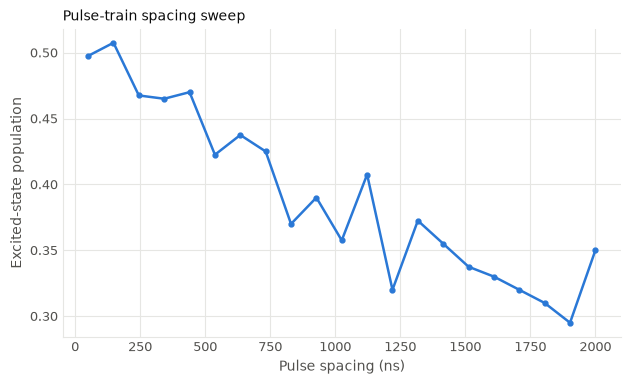

In [11]:
T_DECAY = 12_000.0  # ns; decay time assumed by the mock measurement model.


def decay(bus, env):
    """Return an exponential population decay based on the pulse-train duration."""
    total_ns = N_PULSES * (env["spacing"] + PULSE_NS)
    return 0.5 * np.exp(-total_ns / T_DECAY)


qprogram = qp.QProgram(label="pulse_train_scan")
spacing = qprogram.variable("spacing", label="Pulse spacing", units="ns")

with qprogram.average(shots=400):
    with qprogram.sweep(spacing, qp.Linspace(50, 2000, 21)):
        qprogram.call(pulse_train, "q0/drive", spacing)
        m_train = qprogram.measure("q0/readout", "probe", "weights", fields=(MeasurementField.STATE,))

qprogram = qprogram.expand()
qprogram = qprogram.with_waveforms(library)
result = qp.simulate(qprogram, model=qp.MockMeasurementModel(p_excited=decay, seed=3))

result.plot(
    m_train,
    field=MeasurementField.STATE,
    value=Quantity("Excited-state population"),
    style=Style(markers=True),
    title="Pulse-train spacing sweep",
)
plt.show()

## 3.2 Conditionals

Conditionals choose which operations to execute based on a measurement taken earlier in the same run. Use `qprogram.if_(condition)`, `qprogram.elif_(condition)`, and `qprogram.else_()` as context managers to build a `Conditional` node.

The condition reads a classified measurement state, so the measurement must request `MeasurementField.STATE`. A handle's `state` proxy supports symbolic comparisons such as `handle.state == 1`. You can also write `qp.eq(handle.state, 1)`.

The example below plays a corrective pulse for state 1 and waits for state 0. `PI_NS` specifies the assumed corrective-pulse duration, so the wait represents the same duration in the other branch. The `else_` branch is included to demonstrate the complete syntax.

In [12]:
PI_NS = 40  # ns; assumed corrective-pulse duration used for the alternative wait.

qprogram = qp.QProgram(label="one_chain")
m_chain = qprogram.measure("q0/readout", "probe", "weights", fields=(MeasurementField.STATE,))

with qprogram.if_(m_chain.state == 1):
    qprogram.play("q0/drive", "pi")
with qprogram.elif_(m_chain.state == 0):
    qprogram.wait("q0/drive", PI_NS)
with qprogram.else_():
    qprogram.sync()

print(qp.dumps(qprogram))

#!QProgram 0.2

metadata:
  label: "one_chain"

body:
  measure "q0/readout" "probe" "weights" name="m0" fields=["state"]
  if m0.state == 1:
    play "q0/drive" "pi"
  elif m0.state == 0:
    wait "q0/drive" 40
  else:
    sync



### Supported conditions

A condition must be a single equality or inequality comparison between a classified state and an integer, or between two classified states. Combined logical conditions, ordinary variables, floating-point values, and ordered comparisons are not supported yet. Each example below shows one unsupported condition.

In [13]:
qprogram = qp.QProgram(label="refusals")
m_scratch = qprogram.measure("q0/readout", "probe", "weights", fields=(MeasurementField.STATE,))
counter = qprogram.variable("counter")

# A conditional accepts one state comparison, not a combination of comparisons.
try:
    qprogram.if_((m_scratch.state == 1) & (m_scratch.state == 0))
except (qp.ValidationError, TypeError) as exc:
    print(exc)

if_() expects a Comparison condition such as `handle.state == 0` or `handle.state != 1`; got LogicalBinaryOp


In [14]:
# Ordinary variables cannot be used as the source of a conditional state comparison.
try:
    qprogram.if_(qp.eq(counter, 1))
except (qp.ValidationError, TypeError) as exc:
    print(exc)

if_() condition must reference at least one measurement-state ref (e.g. `handle.state`); got a comparison of Variable and Constant


In [15]:
# Compare the state with an integer, such as 1, rather than a float.
try:
    qprogram.if_(m_scratch.state == 1.0)
except (qp.ValidationError, TypeError) as exc:
    print(exc)

handle.state can only be compared to int, another handle.<field>, or a MeasurementRef; got float


In [16]:
# Ordered comparisons such as < are not supported for classified states.
try:
    qprogram.if_(m_scratch.state < 1)
except (qp.ValidationError, TypeError) as exc:
    print(exc)

'<' not supported between instances of '_HandleFieldAccess' and 'int'


Branches must be adjacent at the same nesting level. An `else_` must immediately follow an `if_` or `elif_`; placing another operation between them breaks the chain.

Other checks require the complete program. Referencing a measurement that did not request a state produces a `missing-classification` diagnostic. Referencing a measurement that is absent from the program produces `unknown-measurement`. `qp.validate` returns these diagnostics, while execution reports the errors as exceptions. Section 3.6 explains how to inspect diagnostics and execution plans.

In [17]:
qprogram = qp.QProgram(label="no_classification")
m_iq = qprogram.measure("q0/readout", "probe", "weights")  # The default fields include I/Q, but not the classified state.
with qprogram.if_(m_iq.state == 1):
    qprogram.play("q0/drive", "pi")

diagnostics, plan = qp.validate(qprogram, qp.reference_capabilities())
for diagnostic in diagnostics:
    print(diagnostic)  # Explains that the measurement did not request a classified state.

[error] missing-classification: Conditional references m0.state, but the measurement does not request state classification (add MeasurementField.STATE to fields=) (at body[1])


### Results from conditional branches

A conditional does not add a result dimension. Measurements inside its branches retain the dimensions of their enclosing sweeps. Result positions where a branch was not executed contain `NaN`.

In the example below, the first measurement deterministically selects one branch for each sweep point. The two branch results therefore have complementary missing values, and `combine_first` combines them into one array.

This combination is appropriate for the deterministic example. If averaging includes shots that take different branches at the same point, both arrays may contain values there. `combine_first` selects the first available value; it does not calculate a combined average.

In [18]:
qprogram = qp.QProgram(label="two_arms")
level = qprogram.variable("level", label="Herald level", units="DAC units")

with qprogram.sweep(level, qp.Linspace(0.0, 1.0, 4)):
    herald = qprogram.measure("q0/readout", "probe", "weights", name="herald", fields=(MeasurementField.STATE,))
    with qprogram.if_(herald.state == 1):
        m_up = qprogram.measure("q0/readout", "probe", "weights", name="up", fields=(MeasurementField.STATE,))
    with qprogram.else_():
        m_down = qprogram.measure(
            "q0/readout", "probe", "weights", name="down", fields=(MeasurementField.STATE,)
        )

# The model reports state 1 for level >= 0.5, selecting each branch at two points.
heralded = qp.MockMeasurementModel(p_excited=lambda bus, env: float(env["level"] >= 0.5))
arms = qp.simulate(qprogram, model=heralded)

up_arm = arms.get(m_up, field=MeasurementField.STATE)
down_arm = arms.get(m_down, field=MeasurementField.STATE)

print("level:", up_arm.coords["level"].values)
print("if branch:", up_arm.values)  # NaN where the if branch was skipped.
print("else branch:", down_arm.values)  # NaN where the else branch was skipped.

combined = up_arm.combine_first(down_arm)  # Fill the missing values from the other branch.
print("combined:", combined.values)
print("dims:", combined.dims)  # The conditional adds no extra dimension.

level: [0.         0.33333333 0.66666667 1.        ]
if branch: [nan nan  1.  1.]
else branch: [ 0.  0. nan nan]
combined: [0. 0. 1. 1.]
dims: ('level',)


## 3.3 Custom waveforms

To define a waveform, subclass `qp.waveforms.Waveform` and implement two methods:

- `envelope(resolution=1)` returns the samples at the requested spacing in nanoseconds.
- `get_duration()` returns the waveform duration in nanoseconds.

The base class provides analysis and plotting methods, notebook display, structural equality, and concatenation with `+`.

The `HalfSine` example samples a positive half-period of a sine wave. Its sample grid includes the starting zero but excludes the final endpoint.

duration: 40 ns
samples: [0.         0.03295282 0.06570248 0.09804705 0.12978714 0.16072704
 0.19067601 0.2194494  0.24686981 0.27276818 0.29698485 0.31937051
 0.33978714 0.35810887 0.37422274 0.3880294  0.39944374 0.40839537
 0.4148291  0.41870528 0.42       0.41870528 0.4148291  0.40839537
 0.39944374 0.3880294  0.37422274 0.35810887 0.33978714 0.31937051
 0.29698485 0.27276818 0.24686981 0.2194494  0.19067601 0.16072704
 0.12978714 0.09804705 0.06570248 0.03295282]
area: 10.673237413227127
peak: 0.42
structurally equal: True


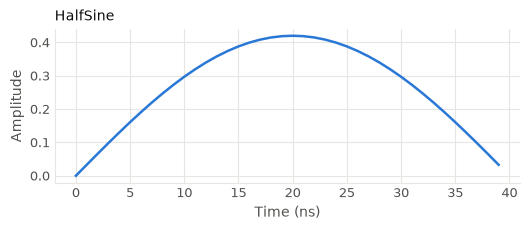

In [19]:
class HalfSine(qp.waveforms.Waveform):
    """Sample a positive sine half-period, excluding the final endpoint."""

    def __init__(self, amplitude: float, duration: int) -> None:
        self.amplitude = amplitude
        self.duration = duration

    def envelope(self, resolution: int = 1) -> np.ndarray:
        sample_count = self.duration // resolution
        phase = np.linspace(0.0, np.pi, sample_count, endpoint=False)
        return self.amplitude * np.sin(phase)

    def get_duration(self) -> int:
        return self.duration


shape = HalfSine(amplitude=0.42, duration=40)

print("duration:", shape.get_duration(), "ns")
print("samples:", shape.envelope())
print("area:", shape.area())
print("peak:", shape.peak_amplitude())
print("structurally equal:", shape == HalfSine(amplitude=0.42, duration=40))

shape.plot()
plt.show()

In [20]:
# This implementation only handles numbers; it does not evaluate expressions.
qprogram = qp.QProgram(label="unbound")
amp = qprogram.variable("amp")
try:
    HalfSine(amplitude=amp, duration=40).envelope()
except TypeError as exc:
    print("expression handling error:", exc)

expression handling error: Cannot use ndarray in an Expression; expected Expression, handle.<field>, int, or float


### Supporting variables and expressions

To accept a swept parameter, a waveform must handle a `qp.Expression` as well as a numeric value. Update the type annotations to describe both forms, then evaluate expressions when their values are needed. Changing the annotation alone does not change the calculation.

The implementation below checks each parameter with `isinstance(..., qp.Expression)` and evaluates expressions with `evaluate_or_raise()`. An unassigned variable then produces `qp.UnassignedVariableError`.

Both `envelope()` and `get_duration()` resolve the parameters they use. Duration must be available independently because other waveform objects may request it without first generating the samples.

In [21]:
class HalfSine(qp.waveforms.Waveform):
    """A sine half-period with numeric or symbolic amplitude and duration."""

    def __init__(self, amplitude: float | qp.Expression, duration: int | qp.Expression) -> None:
        self.amplitude = amplitude
        self.duration = duration

    def envelope(self, resolution: int = 1) -> np.ndarray:
        amplitude = self.amplitude
        if isinstance(amplitude, qp.Expression):
            amplitude = amplitude.evaluate_or_raise()

        # get_duration() handles a numeric or symbolic duration.
        sample_count = self.get_duration() // resolution
        phase = np.linspace(0.0, np.pi, sample_count, endpoint=False)
        return amplitude * np.sin(phase)

    def get_duration(self) -> int:
        duration = self.duration
        if isinstance(duration, qp.Expression):
            duration = duration.evaluate_or_raise()
        return int(duration)


qprogram = qp.QProgram(label="unbound")
amp = qprogram.variable("amp")
symbolic_shape = HalfSine(amplitude=amp, duration=40)

# The waveform can handle the expression, but the variable still needs a value.
try:
    symbolic_shape.envelope()
except qp.UnassignedVariableError as exc:
    print(exc)

amp.set_value(0.42)
print(symbolic_shape.envelope())  # Assigning the value makes sampling possible.

Cannot evaluate expression Variable('amp'): unassigned variable(s) {Variable('amp')}
[0.         0.03295282 0.06570248 0.09804705 0.12978714 0.16072704
 0.19067601 0.2194494  0.24686981 0.27276818 0.29698485 0.31937051
 0.33978714 0.35810887 0.37422274 0.3880294  0.39944374 0.40839537
 0.4148291  0.41870528 0.42       0.41870528 0.4148291  0.40839537
 0.39944374 0.3880294  0.37422274 0.35810887 0.33978714 0.31937051
 0.29698485 0.27276818 0.24686981 0.2194494  0.19067601 0.16072704
 0.12978714 0.09804705 0.06570248 0.03295282]


### Registering a waveform

The class can already generate samples and plots. Register it to support `.qp` serialisation and capability validation.

`qp.register_waveform(HalfSine)` registers the constructor name used by `qp.dumps` and `qp.loads`. Public attributes are written to the file and passed back to `__init__` when loading. Their names and values must therefore match the constructor arguments. Keep derived or cached attributes private by prefixing their names with an underscore.

`qp.register_waveform_token(HalfSine, "waveform.half_sine")` adds a specific capability requirement. Without that token, the waveform requests only the general `waveform.single` capability.

The serialisation registry is global and keyed by class name. Redefining the class creates a new Python class object, so registering that name again raises `ValueError`. The guard below catches an existing registration; it does not replace the registered class. Restart the kernel before testing a changed implementation under the same name. Waveform-token registration is idempotent.

In [22]:
try:
    qp.register_waveform(HalfSine)
except ValueError as exc:
    print("already registered in this kernel:", exc)

qp.register_waveform_token(HalfSine, "waveform.half_sine")

qprogram = qp.QProgram(label="half_sine_scan")
flux_amp = qprogram.variable("flux_amp", label="Flux amplitude", units="DAC units")
with qprogram.sweep(flux_amp, qp.Linspace(0.0, 0.5, 5)):
    qprogram.play("q0/flux", HalfSine(amplitude=flux_amp, duration=40))

text = qp.dumps(qprogram)
print(text)
qprogram = qp.loads(text)
print("serialised text preserved after loading:", qp.dumps(qprogram) == text)

one_play = qp.operations.Play("q0/flux", HalfSine(amplitude=0.42, duration=40))
print("required capabilities:", one_play.required_capabilities())

#!QProgram 0.2

metadata:
  label: "half_sine_scan"

body:
  var flux_amp label="Flux amplitude" units="DAC units"

  for flux_amp in Linspace(start=0.0, stop=0.5, num=5):
    play "q0/flux" HalfSine(amplitude=flux_amp, duration=40)

serialised text preserved after loading: True
required capabilities: {'op.play', 'waveform.half_sine', 'waveform.single'}


### Custom sweep sources

A custom sweep source follows a similar pattern. Subclass `qp.SweepSource`, declare `KIND` and `TOKEN`, and implement `length()` and `values()`. Store constructor parameters as matching public attributes so the source can be serialised.

`KIND="linear"` declares a sequence of the form `start + step * i`. A supporting platform can use that structure to generate values with an incrementing loop. Use `KIND="arbitrary"` when the values are supplied as a table. `TOKEN` identifies the source's capability requirement.

`qp.register_sweep_source` registers both serialisation support and the capability token. The `Chebyshev` source below generates values concentrated near the interval's endpoints, demonstrating a source with nonuniform spacing.

In [23]:
class Chebyshev(qp.SweepSource):
    """Generate Chebyshev nodes concentrated near the interval endpoints."""

    KIND = "arbitrary"
    TOKEN = "sweep.chebyshev"

    def __init__(self, start: float, stop: float, num: int) -> None:
        self.start = start
        self.stop = stop
        self.num = num

    def length(self) -> int:
        return self.num

    def values(self) -> np.ndarray:
        k = np.arange(self.num)
        angles = np.pi * (2 * k + 1) / (2 * self.num)
        unit = -np.cos(angles)  # Nodes between -1 and 1, ordered from left to right.
        # Scale the normalised nodes into the requested interval.
        return self.start + (unit + 1) / 2 * (self.stop - self.start)


try:
    qp.register_sweep_source(Chebyshev)
except ValueError as exc:
    print("already registered in this kernel:", exc)

nodes = Chebyshev(start=4.80e9, stop=4.90e9, num=7)
print("frequencies in GHz:", nodes.values() / 1e9)
print("required capabilities:", nodes.tokens())
print("under Repeat:", qp.Repeat(nodes, times=2).tokens())  # Includes the custom source's token.

qprogram = qp.QProgram(label="chebyshev_scan")
freq = qprogram.variable("freq", label="Drive frequency", units="Hz")
with qprogram.sweep(freq, nodes):
    qprogram.set_frequency("q0/drive", freq)

print(qp.dumps(qprogram))

frequencies in GHz: [4.8012536  4.81090843 4.82830581 4.85       4.87169419 4.88909157
 4.8987464 ]
required capabilities: {'sweep.arbitrary', 'sweep.chebyshev'}
under Repeat: {'sweep.arbitrary', 'sweep.repeat', 'sweep.chebyshev'}
#!QProgram 0.2

metadata:
  label: "chebyshev_scan"

body:
  var freq label="Drive frequency" units="Hz"

  for freq in Chebyshev(start=4800000000.0, stop=4900000000.0, num=7):
    set_frequency "q0/drive" freq



## 3.4 Vendor extensions

A vendor extension adds operations for a particular instrument. It is a separate Python package that depends on `qprogram` and registers its additions when imported.

This tutorial uses `qprogram-qblox`, which describes a Qblox sequencer, and `qprogram-qdac`, which describes a QDevil QDAC channel. These packages provide language extensions without connecting to hardware.

An extension can declare an entry point so QProgram can discover it automatically:

```toml
[project.entry-points."qprogram.vendors"]
qblox = "qprogram_qblox"
```

The entry-point name identifies the vendor namespace, and its value names the module to import. When a `.qp` header requires that vendor, QProgram looks in the `qprogram.vendors` entry-point group and activates the extension.

The next cell loads a program that requires `qblox`. In a fresh kernel, the first check should report that `qprogram_qblox` has not been imported; loading the program imports it. Rerunning the cell reports the module as already imported.

In [24]:
FROM_A_COLLEAGUE = """#!QProgram 0.2

require qblox 0.2

body:
  qblox.set_markers "q0/drive" "0001"
"""

print("qprogram_qblox imported before the load:", "qprogram_qblox" in sys.modules)
qprogram = qp.loads(FROM_A_COLLEAGUE)
print("qprogram_qblox imported after the load:", "qprogram_qblox" in sys.modules)
print(qp.dumps(qprogram))

qprogram_qblox imported before the load: False
qprogram_qblox imported after the load: True
#!QProgram 0.2

require qblox 0.2

body:
  qblox.set_markers "q0/drive" "0001"



### Namespaces

Each extension registers a namespace on `QProgram` through which you call its operations.

In [25]:
import qprogram_qblox  # Register the Qblox namespace.
import qprogram_qdac  # Register the QDAC namespace.

# The imports make both namespaces available on a regular QProgram.
qprogram = qp.QProgram(label="vendor_operations")
qprogram.qblox.set_markers("q0/drive", "0001")
qprogram.qdac.set_offset("q0/flux", 0.42)
print(qp.dumps(qprogram))

#!QProgram 0.2

require qblox 0.2
require qdac 0.2

metadata:
  label: "vendor_operations"

body:
  qblox.set_markers "q0/drive" "0001"
  qdac.set_offset "q0/flux" 0.42



Call vendor operations through their namespace, such as `qprogram.qdac.set_offset(...)`. The serialised header includes a sorted `require` line for each vendor used by the program. These requirements use major and minor versions; patch versions are omitted.

Mixins provide static typing and editor completion for these namespaces. The namespaces also resolve dynamically without a mixin. The example below combines both mixins in one program class, then adds operations from both extensions.

In [26]:
from qprogram.waveforms import Ramp
from qprogram_qblox import QbloxMixin
from qprogram_qdac import QdacMixin

class RackProgram(QbloxMixin, QdacMixin, qp.QProgram):
    """Expose typed builder methods from both vendor extensions."""


qprogram = RackProgram(label="bias_then_acquire")
qprogram.qdac.set_offset("q0/flux", 0.42)
qprogram.qdac.play("q0/flux", Ramp(from_amplitude=0.0, to_amplitude=0.3, duration=400), dwell=200)
qprogram.qblox.acquire("q0/readout", "weights")

print(qp.dumps(qprogram))

#!QProgram 0.2

require qblox 0.2
require qdac 0.2

metadata:
  label: "bias_then_acquire"

body:
  qdac.set_offset "q0/flux" 0.42
  qdac.play "q0/flux" Ramp(from_amplitude=0.0, to_amplitude=0.3, duration=400) dwell=200
  qblox.acquire "q0/readout" "weights" name="m0"



A `require` line is validated during loading. The next three cells demonstrate an unavailable vendor, a required version newer than the installed extension, and a version containing a patch component. Each produces a `qp.ParseError` with an explanation.

In [27]:
# This vendor is not installed or registered.
try:
    qp.loads("""#!QProgram 0.2

require acme_rack 0.1

body:
""")
except qp.ParseError as exc:
    print(exc)

Line 3: file requires vendor 'acme_rack' 0.1 but no matching extension is registered in this environment — install the package that declares the 'qprogram.vendors' entry point for 'acme_rack', or import the extension before loading


In [28]:
# The installed QDAC extension is version 0.2, below the required version.
try:
    qp.loads("""#!QProgram 0.2

require qdac 0.9

body:
""")
except qp.ParseError as exc:
    print(exc)

Line 3: file requires qdac 0.9, newer than the installed qdac 0.2.0 — install qdac 0.9 or newer


In [29]:
# A require line accepts major.minor, without a patch version.
try:
    qp.loads("""#!QProgram 0.2

require qdac 0.2.0

body:
""")
except qp.ParseError as exc:
    print(exc)

Line 3: file version '0.2.0' must be exactly major.minor


When loading an older format version, QProgram applies registered migrations in version order. Migrations transform the text in memory; loading does not modify the source file. Serialising the loaded program writes the current format version.

Use `qp.serialization.known_migrations` to inspect registered migrations. With the versions used in this tutorial, the example below loads its `0.1` header and vendor requirement, then serialises both as `0.2`.

In [30]:
FROM_LAST_YEAR = """#!QProgram 0.1

require qdac 0.1

body:
  qdac.set_offset "q0/flux" 0.42
"""

print("registered migrations:", qp.serialization.known_migrations("qp"))
qprogram = qp.loads(FROM_LAST_YEAR)
print(qp.dumps(qprogram))  # The format header and vendor requirement now use version 0.2.

registered migrations: ()
#!QProgram 0.2

require qdac 0.2

body:
  qdac.set_offset "q0/flux" 0.42



## 3.5 Capabilities, plans, and transformations

A capability descriptor declares which parts of a program a platform can execute. The validator uses it to report unsupported features and determine the available execution domains.

A capability token is a string identifying a feature, such as `op.set_offset` for a flux offset operation or `waveform.iq` for an IQ waveform. Program nodes report the tokens they require, and capability profiles list the tokens they support.

`qp.PlatformCapabilities` contains three fields:

- `bus` maps an element kind and bus kind to a profile. For example, `("q", "flux")` selects the qubit flux profile.
- `platform` describes support for features that are not tied to a bus, such as blocks and expressions.
- `default_bus_profile` applies when no specific bus entry matches. It also applies to plain string bus names, which do not carry schema metadata for selecting an entry.

The `bus` mapping values, `platform`, and `default_bus_profile` are `qp.BusCapabilities` objects. Each has an `rt` component for real-time execution and a `host` component for execution through the control computer. Either component may be `None`.

Each available component is a `qp.CompilerCapabilities` object containing a profile name, version, capability tokens, limits, predicates, and supported vendor versions.

In [31]:
schema = BusSchema.flux_tunable_transmon()
q = schema.q
reference = qp.reference_capabilities()

print("bus profiles:", reference.bus)  # Unlisted buses use the default profile.
print("platform profile:", reference.platform.rt.profile)
print("platform version:", reference.platform.rt.version)
print("default bus profile:", reference.default_bus_profile.rt.profile)
print("supported domains:", reference.default_bus_profile.supported_domains())
bus_slot = reference.default_bus_profile
host_only_tokens = bus_slot.host.capabilities - bus_slot.rt.capabilities
print("capabilities available only on the host:", host_only_tokens)

bus profiles: {}
platform profile: qprogram-reference-platform
platform version: (0, 1, 0)
default bus profile: qprogram-reference-bus
supported domains: frozenset({'rt', 'host'})
capabilities available only on the host: frozenset({'op.get_parameter', 'op.set_parameter'})


The reference descriptor supports parameter reads and writes in the host domain. These operations access platform configuration through `get_parameter` and `set_parameter`.

The validator selects profiles from the node's context. Blocks use the platform profile. An operation targeting a bus uses that bus's profile; operations involving several buses must be supported by all relevant profiles. Expression tokens beginning with `expr.` are checked against the platform profile, including when an expression appears in a bus operation.

Use `node.required_capabilities()` to inspect requirements and `CompilerCapabilities.supports(token)` to check whether a profile supplies a capability. The next cells demonstrate both sides of this check.

The `qprogram` below is the shared program for this section. It sweeps the flux bias from -0.05 V to 0.15 V inside 200 averaging passes. The examples reuse this program and change only the capability descriptor. Examples that need a different sequence define a separately named program, leaving `qprogram` unchanged.

In [32]:
qprogram = qp.QProgram(label="flux_sweep", schema=schema)
bias = qprogram.variable("bias", label="Flux bias", units="V")
with qprogram.average(shots=200):
    with qprogram.sweep(bias, qp.Linspace(-0.05, 0.15, 41)):
        qprogram.set_offset(q[0].flux, bias)
        qprogram.set_frequency(q[0].drive, 4.85e9)
        qprogram.play(q[0].drive, "pi")
        qprogram.sync([q[0].drive, q[0].readout])
        qprogram.measure(q[0].readout, "probe", "weights", name="m0", fields=(MeasurementField.STATE,))

for node in qprogram.body.walk():
    if node is not qprogram.body:  # Skip the root block returned by walk().
        print(type(node).__name__, node.required_capabilities())

Average {'block.average'}
Sweep {'block.sweep', 'sweep.linspace', 'sweep.linear'}
SetOffset {'expr.variable', 'op.set_offset'}
SetFrequency {'op.set_frequency'}
Play {'op.play', 'waveform.alias'}
Sync {'op.sync'}
Measure {'measure.fields.state', 'op.measure', 'waveform.iq', 'waveform.alias'}


In [33]:
flux_slot = reference.for_bus(q[0].flux)

# Check the same operation in each execution domain.
print("set_offset in real time:", flux_slot.rt.supports("op.set_offset"))
print("set_offset on the host:", flux_slot.host.supports("op.set_offset"))
print("set_parameter in real time:", flux_slot.rt.supports("op.set_parameter"))
print("set_parameter on the host:", flux_slot.host.supports("op.set_parameter"))

set_offset in real time: True
set_offset on the host: True
set_parameter in real time: False
set_parameter on the host: True


### Named capability profiles

The reference descriptor is useful for examples. An extension can publish a named `qp.Profile` to describe its own supported features, and `qp.CompilerCapabilities.from_profile(name)` resolves it.

A profile can use `extends` to inherit another profile. It adds to the parent's capability tokens and predicates while overriding limits with the same keys. `qprogram-base-v1` provides core blocks, expressions, and sweeps without bus operations, so it can serve as a starting point for other profiles.

Registering an equal profile again is allowed. Predicate equality depends on the callable objects, so keep their identities stable when reusing a registration. Defining a new lambda or re-executing a function definition creates a different object.

In [34]:
qp.register_capability_tokens("vendor.benchtop.dac_ramp")
BENCHTOP_FLUX = qp.Profile(
    name="benchtop-flux-v1",
    version=(1, 0, 0),
    extends="qprogram-base-v1",
    capabilities=frozenset({"op.set_offset", "op.wait", "vendor.benchtop.dac_ramp"}),
    limits={"max_loop_nesting": 2},
)
qp.register_profile(BENCHTOP_FLUX)

merged = qp.CompilerCapabilities.from_profile("benchtop-flux-v1")

print("inherited sweep support:", merged.supports("block.sweep"))
print("added offset support:", merged.supports("op.set_offset"))
print("limits:", merged.limits)

inherited sweep support: True
added offset support: True
limits: {'max_loop_nesting': 2}


The vendor extensions from section 3.4 also publish named profiles. The two profiles distinguish different kinds of offset control. `qblox-default-v1` supports the core `op.set_offset` token for offset changes within a sequence. `qdac-default-v1` provides `vendor.qdac.set_offset` for changes dispatched through the host. The separate operation names allow the capability system to distinguish their execution requirements.

In [35]:
import qprogram_qblox  # Register the Qblox profile.
import qprogram_qdac  # Register the QDAC profile.

qblox_half = qp.CompilerCapabilities.from_profile("qblox-default-v1")
qdac_half = qp.CompilerCapabilities.from_profile("qdac-default-v1")

print("Qblox limits:", qblox_half.limits)
print("QDAC limits:", qdac_half.limits)

# These profiles distinguish sequencer offsets from QDAC offsets sent through the host.
print("Qblox supports core set_offset:", qblox_half.supports("op.set_offset"))
print("QDAC supports core set_offset:", qdac_half.supports("op.set_offset"))
print("Qblox supports qdac.set_offset:", qblox_half.supports("vendor.qdac.set_offset"))
print("QDAC supports qdac.set_offset:", qdac_half.supports("vendor.qdac.set_offset"))
print("Qblox supports IQ waveforms:", qblox_half.supports("waveform.iq"))
print("QDAC supports IQ waveforms:", qdac_half.supports("waveform.iq"))

Qblox limits: {'min_wait_duration_ns': 4}
QDAC limits: {'min_dwell_ns': 100}
Qblox supports core set_offset: True
QDAC supports core set_offset: False
Qblox supports qdac.set_offset: False
QDAC supports qdac.set_offset: True
Qblox supports IQ waveforms: True
QDAC supports IQ waveforms: False


### Validating a program

`qp.validate(qprogram, capabilities)` returns a pair containing diagnostics and an execution plan. Validation failures are returned as diagnostics rather than raised as execution exceptions. This lets a caller display all findings and decide how to handle them.

The plan maps nodes to their supported execution domains. Each diagnostic includes a severity, code, message, and information about the affected node. Inspect `severity` to distinguish errors from warnings and use `code` for programmatic handling.

For readable output, print a diagnostic directly or select its fields. Printing an entire list can include node representations that are less useful than the formatted messages.

The following examples use the shared `qprogram` defined at the start of this section. Each defines its own capability descriptor, starting with the reference descriptor.

In [36]:
reference = qp.reference_capabilities()
diagnostics, plan = qp.validate(qprogram, reference)
print("diagnostics:", diagnostics)  # An empty list means no issues were reported.
print("plan entries:", len(plan))

diagnostics: []
plan entries: 7


Now model a flux DAC that receives updates through the host computer. Setting its bus profile's `rt` component to `None` removes real-time support while preserving host support. The `("q", "flux")` entry applies this profile to qubit flux buses; other buses keep the reference defaults.

Capability descriptors are immutable, so `dataclasses.replace` creates modified copies. This example produces warnings about host execution, but the program remains valid.

In [37]:
reference = qp.reference_capabilities()
# Model a flux DAC controlled by the host: its bus has no real-time component.
flux_profile = reference.for_bus(q[0].flux)
host_flux_profile = replace(flux_profile, rt=None)
capabilities = replace(reference, bus={("q", "flux"): host_flux_profile})

diagnostics, plan = qp.validate(qprogram, capabilities)
for diagnostic in diagnostics:
    print(diagnostic)

[warning] forced-host: Block 'Average' falls back to host-side execution: contains host-side-only sub-block 'Sweep'. (at body[0])
[info] reorderable-averaging: Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize(). (at body[0])


A fixed DC source cannot change its offset. In this example, the flux bus has no real-time component and its host component lacks `op.set_offset`, so the operation is unsupported in both domains. Inspect the resulting error diagnostic's fields.

In [38]:
reference = qp.reference_capabilities()
# Model a fixed DC source: the host profile cannot change the flux offset.
flux_host = reference.for_bus(q[0].flux).host
fixed_dc_host = replace(
    flux_host,
    profile="dc-source-v1",
    capabilities=flux_host.capabilities - {"op.set_offset"},
)
fixed_flux_profile = qp.BusCapabilities(rt=None, host=fixed_dc_host)
capabilities = replace(reference, bus={("q", "flux"): fixed_flux_profile})

diagnostics, plan = qp.validate(qprogram, capabilities)
diagnostic = diagnostics[0]  # Inspect the diagnostic for the unsupported offset operation.
print("severity:", diagnostic.severity)
print("code:", diagnostic.code)
print("message:", diagnostic.message)
print("node type:", type(diagnostic.node).__name__)
print("path:", diagnostic.path)
print("formatted path:", qp.format_path(diagnostic.path))
print("capability:", diagnostic.capability)
print("domain:    ", diagnostic.domain)

severity: error
code: missing-capability
message: 'SetOffset' requires capability 'op.set_offset' which is not supported by 'dc-source-v1' (host)
node type: SetOffset
path: (0, 0, 0)
formatted path: body[0][0][0]
capability: op.set_offset
domain:     host


A diagnostic's `message` explains the issue, its `code` identifies the type of problem, and its `path` locates the affected node.

Use `qp.format_path` to format a path, `qp.node_path` to find a node's path, and `qp.resolve_path` to look up a node from a path. For a program loaded with `qp.loads`, `qprogram.source_map` connects paths to source lines.

### Explaining an execution plan

`qp.explain` displays the program with its execution domains and diagnostics. Each row shows a node and indicates support in both domains, only `rt`, only `host`, or neither. Diagnostics and transformation hints appear beside the relevant rows.

In [39]:
reference = qp.reference_capabilities()
print(qp.explain(qprogram, reference))

plan for 'flux_sweep' — errors: 0 · warnings: 0 · info: 0
body
└─ average 200:                                                             [rt|host]
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [rt|host]
      ├─ set_offset q[0].flux bias                                          [rt|host]
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]


For this program, the reference descriptor allows every operation in both domains. The next example uses a descriptor for a host-controlled flux DAC with the same `qprogram`. Removing the flux profile's `rt` component changes the plan without changing the sequence.

In [40]:
reference = qp.reference_capabilities()
# Model a flux DAC controlled by the host: its bus has no real-time component.
flux_profile = reference.for_bus(q[0].flux)
host_flux_profile = replace(flux_profile, rt=None)
capabilities = replace(reference, bus={("q", "flux"): host_flux_profile})

print(qp.explain(qprogram, capabilities))

plan for 'flux_sweep' — errors: 0 · warnings: 1 · info: 1
body
└─ average 200:                                                             [host]     ~ forced-host: contains host-side-only sub-block 'Sweep'  i reorderable-averaging: Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize().
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [host]
      ├─ set_offset q[0].flux bias                                          [host]
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0

`set_offset` uses the flux profile and is restricted to the host domain. That restriction also moves its enclosing sweep and averaging block to the host. The `forced-host` warning identifies the affected block and the operation responsible.

The program is still executable, but the host performs the flux updates during each of the 200 passes over the sweep. The additional hint identifies a possible transformation that can reduce those updates, shown later in this section.

If the flux profile does not support `set_offset` in either domain, the operation has no valid execution domain. The following plan shows this error.

In [41]:
reference = qp.reference_capabilities()
# Model a fixed DC source: the host profile cannot change the flux offset.
flux_host = reference.for_bus(q[0].flux).host
fixed_dc_host = replace(
    flux_host,
    profile="dc-source-v1",
    capabilities=flux_host.capabilities - {"op.set_offset"},
)
fixed_flux_profile = qp.BusCapabilities(rt=None, host=fixed_dc_host)
capabilities = replace(reference, bus={("q", "flux"): fixed_flux_profile})

print(qp.explain(qprogram, capabilities))

plan for 'flux_sweep' — errors: 1 · warnings: 0 · info: 0
body
└─ average 200:                                                             [rt|host]
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [--]
      ├─ set_offset q[0].flux bias                                          [--]       !! missing-capability: 'SetOffset' requires capability 'op.set_offset' which is not supported by 'dc-source-v1' (host)
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]


The unsupported `set_offset` has an error diagnostic and no execution domain. Its enclosing sweep also has no available domain, so inspect the child operation to find the cause. In this plan, the empty domain set propagates one level; the outer averaging row still shows support in both domains. An outer row's domains alone therefore do not establish that the whole program is valid.

### Limits

Limits constrain numeric properties of a program. The core validator reads four keys:

| Limit | Profile used |
|---|---|
| `max_loop_nesting` | Platform profile. |
| `max_parallel_loops` | Platform profile. |
| `max_measurements` | Platform profile. |
| `min_wait_duration_ns` | Profile of the bus targeted by `wait`. |

Profiles can contain additional limits, but declaring a key does not make the core validator enforce it.

For each profile, these limits are read from the `rt` component when it exists, otherwise from `host`. A limit added only to `host` is therefore not checked when the same profile also has an `rt` component. The following cells demonstrate the limits and this distinction.

In [42]:
reference = qp.reference_capabilities()
# Change the rt component, then place it in copies of the enclosing descriptors.
limited_rt = replace(reference.platform.rt, limits={"max_loop_nesting": 1})
limited_platform = replace(reference.platform, rt=limited_rt)
capabilities = replace(reference, platform=limited_platform)

diagnostics, plan = qp.validate(qprogram, capabilities)
print(diagnostics[0])  # average() plus sweep() requires two nesting levels.

[error] limit-exceeded: Program nests loops 2 deep; limit max_loop_nesting=1


In [43]:
reference = qp.reference_capabilities()
# This platform permits no measurements, so the readout is rejected.
no_measurements_rt = replace(reference.platform.rt, limits={"max_measurements": 0})
no_measurements_platform = replace(reference.platform, rt=no_measurements_rt)
capabilities = replace(reference, platform=no_measurements_platform)

diagnostics, plan = qp.validate(qprogram, capabilities)
print(diagnostics[0])

[error] limit-exceeded: Program contains 1 measurements; limit max_measurements=0


In [44]:
reference = qp.reference_capabilities()
# A limit set only on host is not read while an rt component is present.
limited_host = replace(reference.platform.host, limits={"max_loop_nesting": 1})
host_limited_platform = replace(reference.platform, host=limited_host)
capabilities = replace(reference, platform=host_limited_platform)

diagnostics, plan = qp.validate(qprogram, capabilities)
print("diagnostics:", diagnostics)  # Empty: the validator read the unchanged rt limits.

diagnostics: []


### Predicates

Predicates add validation rules beyond capability tokens and numeric limits. Each receives a node and a `qp.ValidationContext`. It yields nothing when the node meets the rule, or yields a diagnostic or domain constraint when action is needed.

The rule below yields an error diagnostic when a flux sweep exceeds the example DAC's supported range. `BIAS_LIMIT`, defined beside the predicate, is the maximum absolute offset in volts. It is set to 0.1 V and is used both in the comparison and in the diagnostic message.

The offset operation contains a variable, so the predicate needs its sweep values. `ctx.binding_loop_of(variable)` finds the loop that assigns the variable, and `loop.source.values()` provides the values to check.

`ctx.sweep_kind_of(variable)` identifies whether the variable has a linear or arbitrary source, or no sweep binding. Other context queries provide loop depth, parallel-loop count, measurement count, requested fields, measurement names, and bus usage.

In [45]:
BIAS_LIMIT = 0.1  # V; maximum absolute offset supported by the example flux DAC.


def flux_within_range(node, ctx):
    """Reject swept offsets whose magnitude exceeds the example DAC limit."""
    if not isinstance(node, qp.operations.SetOffset):
        return  # This rule only checks offset operations.
    if not isinstance(node.offset_path0, qp.Variable):
        return  # This example checks offsets supplied by a swept variable.

    loop = ctx.binding_loop_of(node.offset_path0)
    if loop is None:
        return

    values = loop.source.values()
    max_offset = max(abs(values))  # Largest absolute offset in the sweep.
    if max_offset > BIAS_LIMIT:
        yield qp.Diagnostic(
            severity="error",
            code="benchtop.flux-out-of-range",
            message=f"Flux sweep reaches {max_offset:.2f} V, exceeding the DAC limit of {BIAS_LIMIT} V.",
            node=node,
        )


reference = qp.reference_capabilities()
# Apply the rule to the flux profile in both domains, preserving existing predicates.
flux_profile = reference.for_bus(q[0].flux)
flux_rt = replace(flux_profile.rt, predicates=flux_profile.rt.predicates + (flux_within_range,))
flux_host = replace(flux_profile.host, predicates=flux_profile.host.predicates + (flux_within_range,))
guarded_flux_profile = qp.BusCapabilities(rt=flux_rt, host=flux_host)
capabilities = replace(reference, bus={("q", "flux"): guarded_flux_profile})

diagnostics, plan = qp.validate(qprogram, capabilities)
print(diagnostics[0])  # The sweep reaches 0.15 V, above BIAS_LIMIT.

# Validate a separate, narrower program against the same range rule.
narrow_program = qp.QProgram(label="narrow_scan", schema=schema)
bias = narrow_program.variable("bias", label="Flux bias", units="V")
with narrow_program.sweep(bias, qp.Linspace(-0.05, 0.05, 11)):
    narrow_program.set_offset(q[0].flux, bias)
diagnostics, plan = qp.validate(narrow_program, capabilities)
print("diagnostics:", diagnostics)  # Empty: all offsets are within the supported range.

[error] benchtop.flux-out-of-range: Flux sweep reaches 0.15 V, exceeding the DAC limit of 0.1 V. (at body[0][0][0])
diagnostics: []


A predicate can yield `qp.DomainConstraint` to restrict a block's execution domains without rejecting the program. The constraint names the block, the domains to exclude, and a reason that can appear in a warning.

The example below restricts the loop that steps a network-controlled DAC to host execution. The constraint must target a block; targeting an operation produces a validation error. `ctx.binding_loop_of` identifies the sweep block to restrict.

This differs from removing real-time support from a bus profile. A domain constraint restricts the loop while leaving the operation's declared capabilities unchanged. Removing the bus's `rt` component also restricts the operation itself. This distinction affects whether the transformation below applies.

In [46]:
def restrict_flux_sweep_to_host(node, ctx):
    """Restrict the DAC sweep to host execution without rejecting the program."""
    if not isinstance(node, qp.operations.SetOffset):
        return
    if not isinstance(node.offset_path0, qp.Variable):
        return

    loop = ctx.binding_loop_of(node.offset_path0)
    if loop is not None:
        yield qp.DomainConstraint(
            node=loop,  # Restrict the sweep block, not the offset operation.
            exclude=frozenset({"rt"}),
            reason="flux DAC updates require host network communication",
        )


reference = qp.reference_capabilities()
# Keep both domains on the flux operation; the predicate restricts its sweep block.
flux_profile = reference.for_bus(q[0].flux)
flux_rt = replace(flux_profile.rt, predicates=flux_profile.rt.predicates + (restrict_flux_sweep_to_host,))
flux_host = replace(flux_profile.host, predicates=flux_profile.host.predicates + (restrict_flux_sweep_to_host,))
constrained_flux_profile = qp.BusCapabilities(rt=flux_rt, host=flux_host)
capabilities = replace(reference, bus={("q", "flux"): constrained_flux_profile})

print(qp.explain(qprogram, capabilities))

plan for 'flux_sweep' — errors: 0 · warnings: 1 · info: 0
body
└─ average 200:                                                             [host]     ~ forced-host: contains host-side-only sub-block 'Sweep' (flux DAC updates require host network communication)
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [host]
      ├─ set_offset q[0].flux bias                                          [rt|host]
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]


### Optimising the loop arrangement

When the flux bus supports only host execution, the averaging block executes through the host because it contains the flux sweep. The example below applies this capability descriptor to the shared `qprogram`. `qp.optimize(qprogram, capabilities)` can transform this supported pattern by moving the sweep outside the averaging block and moving the flux update before averaging.

The function returns a new program. Keep it as `optimized_program` so you can compare its body with the original `qprogram`, then use `qp.explain` to inspect the resulting plan.

In [47]:
reference = qp.reference_capabilities()
# Model a flux DAC controlled by the host: its bus has no real-time component.
flux_profile = reference.for_bus(q[0].flux)
host_flux_profile = replace(flux_profile, rt=None)
capabilities = replace(reference, bus={("q", "flux"): host_flux_profile})

optimized_program = qp.optimize(qprogram, capabilities)
print(qp.explain(optimized_program, capabilities))
print("host-only flux changes the body:", optimized_program.body != qprogram.body)

plan for 'flux_sweep' — errors: 0 · warnings: 0 · info: 0
body
└─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                    [host]
   ├─ set_offset q[0].flux bias                                             [host]
   └─ average 200:                                                          [rt|host]
      ├─ set_frequency q[0].drive 4850000000.0                              [rt|host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync q[0].drive q[0].readout                                       [rt|host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]
host-only flux changes the body: True


The transformed program sweeps the bias in the outer block, updates the offset once per point, and averages the remaining sequence in real time.

This changes the measurement order. The original program makes 200 passes over the full sweep; the transformed program completes 200 shots at one bias before moving to the next. These arrangements can produce different results when the device drifts over time. Apply the transformation when collecting shots by bias point is appropriate for the experiment.

Moving an operation outside the averaging block also changes how often it executes. This is appropriate for a persistent DC setting, but an operation with other side effects may require a different arrangement. The transformation only moves supported leading host-only operations and does not move them past other operations.

The `reorderable-averaging` hint uses the same applicability check as the transformation. If the hint is absent, this rewrite is not applied. With reference capabilities, all operations in this sequence support real-time execution, so the next example remains unchanged.

In [48]:
reference = qp.reference_capabilities()
# With reference capabilities, no operation needs to move to the host.
optimized_program = qp.optimize(qprogram, reference)
print("reference capabilities change the body:", optimized_program.body != qprogram.body)

reference capabilities change the body: False


An additional nested sweep falls outside this transformation's supported pattern. `nested_sweeps_program` adds a drive-frequency sweep inside the flux sweep. Its body remains unchanged after optimisation.

In [49]:
nested_sweeps_program = qp.QProgram(label="two_sweeps", schema=schema)
bias = nested_sweeps_program.variable("bias", label="Flux bias", units="V")
frequency = nested_sweeps_program.variable("freq", label="Drive frequency", units="Hz")
with nested_sweeps_program.average(shots=200):
    with nested_sweeps_program.sweep(bias, qp.Linspace(-0.05, 0.15, 11)):
        nested_sweeps_program.set_offset(q[0].flux, bias)
        with nested_sweeps_program.sweep(frequency, qp.Linspace(4.85e9 - 50e6, 4.85e9 + 50e6, 11)):
            nested_sweeps_program.set_frequency(q[0].drive, frequency)
            nested_sweeps_program.play(q[0].drive, "pi")
            nested_sweeps_program.measure(q[0].readout, "probe", "weights", name="m0", fields=(MeasurementField.STATE,))

reference = qp.reference_capabilities()
# Model a flux DAC controlled by the host: its bus has no real-time component.
flux_profile = reference.for_bus(q[0].flux)
host_flux_profile = replace(flux_profile, rt=None)
capabilities = replace(reference, bus={("q", "flux"): host_flux_profile})

optimized_program = qp.optimize(nested_sweeps_program, capabilities)
print("additional nested sweep changes the body:", optimized_program.body != nested_sweeps_program.body)

additional nested sweep changes the body: False


Calling `sync()` without explicit buses includes the host-only flux bus. The separate `broadcast_sync_program` uses this synchronisation in the middle of the sequence, which prevents the reordering. Inspect its unchanged plan beside the body comparison.

In [50]:
broadcast_sync_program = qp.QProgram(label="bare_sync", schema=schema)
bias = broadcast_sync_program.variable("bias", label="Flux bias", units="V")
with broadcast_sync_program.average(shots=200):
    with broadcast_sync_program.sweep(bias, qp.Linspace(-0.05, 0.15, 41)):
        broadcast_sync_program.set_offset(q[0].flux, bias)
        broadcast_sync_program.play(q[0].drive, "pi")
        broadcast_sync_program.sync()  # Include every bus, including the host-only flux bus.
        broadcast_sync_program.measure(q[0].readout, "probe", "weights", name="m0", fields=(MeasurementField.STATE,))

reference = qp.reference_capabilities()
# Model a flux DAC controlled by the host: its bus has no real-time component.
flux_profile = reference.for_bus(q[0].flux)
host_flux_profile = replace(flux_profile, rt=None)
capabilities = replace(reference, bus={("q", "flux"): host_flux_profile})

optimized_program = qp.optimize(broadcast_sync_program, capabilities)
print("broadcast sync changes the body:", optimized_program.body != broadcast_sync_program.body)
print(qp.explain(optimized_program, capabilities))

broadcast sync changes the body: False
plan for 'bare_sync' — errors: 0 · warnings: 1 · info: 0
body
└─ average 200:                                                             [host]     ~ forced-host: contains host-side-only sub-block 'Sweep'
   └─ for bias in Linspace(start=-0.05, stop=0.15, num=41):                 [host]
      ├─ set_offset q[0].flux bias                                          [host]
      ├─ play q[0].drive "pi"                                               [rt|host]
      ├─ sync                                                               [host]
      └─ measure q[0].readout "probe" "weights" name="m0" fields=["state"]  [rt|host]


A `DomainConstraint` on the loop also does not produce the hint. The operations retain real-time support, so there is no leading group of host-only operations to move. The following example defines the loop constraint and applies it to the shared `qprogram` before checking the transformation.

In [51]:
def restrict_flux_sweep_to_host(node, ctx):
    """Restrict the DAC sweep to host execution without rejecting the program."""
    if not isinstance(node, qp.operations.SetOffset):
        return
    if not isinstance(node.offset_path0, qp.Variable):
        return

    loop = ctx.binding_loop_of(node.offset_path0)
    if loop is not None:
        yield qp.DomainConstraint(
            node=loop,  # Restrict the sweep block, not the offset operation.
            exclude=frozenset({"rt"}),
            reason="flux DAC updates require host network communication",
        )


reference = qp.reference_capabilities()
# Keep both domains on the flux operation; the predicate restricts its sweep block.
flux_profile = reference.for_bus(q[0].flux)
flux_rt = replace(flux_profile.rt, predicates=flux_profile.rt.predicates + (restrict_flux_sweep_to_host,))
flux_host = replace(flux_profile.host, predicates=flux_profile.host.predicates + (restrict_flux_sweep_to_host,))
constrained_flux_profile = qp.BusCapabilities(rt=flux_rt, host=flux_host)
capabilities = replace(reference, bus={("q", "flux"): constrained_flux_profile})

optimized_program = qp.optimize(qprogram, capabilities)
print("loop constraint changes the body:", optimized_program.body != qprogram.body)

loop constraint changes the body: False


## 3.6 Implementing a platform

A platform implements the interface used to inspect resources, validate programs, and execute them. `qp.PlatformProtocol` requires six members:

| Member | Purpose |
|---|---|
| `get_bus_schema()` | Return the bus schema. |
| `get_buses()` | List the available buses. |
| `get_parameters(bus)` | List configuration parameters for one bus. |
| `get_global_parameters()` | List parameters that are not associated with a bus. |
| `capabilities` | Return the platform's capability descriptor. |
| `execute(qprogram)` | Execute a program and return a `QProgramResult`. |

The base class implements `validate`, `plan`, and `explain` using the capability descriptor. Streaming is optional; the default `stream` implementation raises an error.

An `execute` implementation should validate the program first, raise `qp.UnsupportedOperationError` for error diagnostics, and report warnings without treating them as errors. This is an implementation convention, so the platform must include that logic explicitly.

### A minimal platform implementation

`BenchtopRack` implements all six required members. This example exposes one flux-tunable qubit and a `dac_range` parameter on its flux bus. It stores the schema, capabilities, and parameter values, and checks diagnostics before running a program.

For this example, execution delegates to `ReferencePlatform`. A hardware platform would instead compile the program, send it to the instruments, run it, and assemble the results. The protocol leaves those steps to the implementation.

In [52]:
schema = BusSchema.flux_tunable_transmon()
q = schema.q


class BenchtopRack(qp.PlatformProtocol):
    """Demonstrate the platform interface with a configurable capability descriptor."""

    def __init__(self, schema, capabilities, parameters=None):
        self._schema = schema
        self._capabilities = capabilities
        self.parameters = dict(parameters or {})

    def get_bus_schema(self):
        return self._schema

    def get_buses(self):
        q = self._schema.q
        return [q[0].drive, q[0].readout, q[0].flux]

    def get_parameters(self, bus):
        if bus == self._schema.q[0].flux:
            return ["dac_range"]
        return []

    def get_global_parameters(self):
        return ["fridge_temperature"]

    @property
    def capabilities(self):
        return self._capabilities

    def execute(self, qprogram):
        diagnostics = self.validate(qprogram)
        for diagnostic in diagnostics:
            if diagnostic.severity == "error":
                raise qp.UnsupportedOperationError(str(diagnostic))
            if diagnostic.severity == "warning":
                warnings.warn(str(diagnostic), qp.ExecutionWarning, stacklevel=2)
        # Delegate execution to the reference platform for this tutorial.
        platform = qp.ReferencePlatform(self._schema, parameters=self.parameters)
        return platform.execute(qprogram)

The next program sweeps a flux bias and measures at each point. We describe a platform where flux operations can execute only through the host.

Each bus profile contains an `rt` component for real-time execution and a `host` component for host execution. Setting `rt=None` on the flux profile removes real-time support for that bus. Section 3.6 explains how these components affect the execution plan.

The capability descriptors are immutable, so `dataclasses.replace` creates modified copies. Here, we start from the reference descriptor and change only the flux profile.

In [53]:
qprogram = qp.QProgram(label="flux_sweep", schema=schema)
bias = qprogram.variable("bias", label="Flux bias", units="V")
bias_source = qp.Linspace(-0.05, 0.15, 41)

with qprogram.average(shots=200):
    with qprogram.sweep(bias, bias_source):
        qprogram.set_offset(q[0].flux, bias)
        qprogram.set_frequency(q[0].drive, 4.85e9)
        qprogram.play(q[0].drive, "pi")
        qprogram.sync([q[0].drive, q[0].readout])
        qprogram.measure(
            q[0].readout, "probe", "weights", name="m0", fields=(MeasurementField.STATE,)
        )

In [54]:
reference = qp.reference_capabilities()
slow_dac = replace(reference.default_bus_profile, rt=None)  # Support flux operations in the host domain only.
rack_caps = replace(reference, bus={("q", "flux"): slow_dac})

rack = BenchtopRack(schema, rack_caps, parameters={"q0/flux.dac_range": 0.5})

print("buses:", rack.get_buses())
print("parameters on q0/flux:", rack.get_parameters(q[0].flux))
print("global parameters:", rack.get_global_parameters())

# Execution emits a warning because the flux sweep must run through the host.
run = rack.execute(qprogram)

print("result:", run)
population = run.get("m0", field=MeasurementField.STATE)
print("array:", population.dims, population.shape)

buses: ['q0/drive', 'q0/readout', 'q0/flux']
parameters on q0/flux: ['dac_range']
global parameters: ['fridge_temperature']
result: QProgramResult(1 measurements, names=['m0'])
array: ('bias',) (41,)


/tmp/ipykernel_199852/4157792076.py:12: ExecutionWarning: [warning] forced-host: Block 'Average' falls back to host-side execution: contains host-side-only sub-block 'Sweep'. (at body[0])
  run = rack.execute(qprogram)


The platform returns a result containing a population array and reports an `ExecutionWarning` about host execution. The warning appears in the notebook output.

The next example removes support for `op.set_offset` from the flux bus entirely. Validation then produces an error, and `execute` rejects the program before execution.

In [55]:
host_half = reference.default_bus_profile.host
dc_source = replace(
    host_half,
    profile="dc-source-v1",
    capabilities=host_half.capabilities - {"op.set_offset"},
)
fixed_flux = qp.BusCapabilities(rt=None, host=dc_source)
fixed_caps = replace(reference, bus={("q", "flux"): fixed_flux})

unsupported_rack = BenchtopRack(schema, fixed_caps)
try:
    unsupported_rack.execute(qprogram)
except qp.UnsupportedOperationError as exc:
    print(exc)

[error] missing-capability: 'SetOffset' requires capability 'op.set_offset' which is not supported by 'dc-source-v1' (host) (at body[0][0][0])


### Inherited methods and result construction

`BenchtopRack` inherits `validate`, `plan`, and `explain` from `PlatformProtocol`. The next cell calls the first two without any additional implementation in the subclass.

In [56]:
diagnostics = rack.validate(qprogram)
for diagnostic in diagnostics:
    print(diagnostic)

plan = rack.plan(qprogram)
print("plan entries:", len(plan))

[warning] forced-host: Block 'Average' falls back to host-side execution: contains host-side-only sub-block 'Sweep'. (at body[0])
[info] reorderable-averaging: Block 'Average' runs host-side only because it encloses a host-side sweep; its measurement sequence supports real-time hardware. Moving the sweep outside the average (hoisting the host-side-only setup with it) would let the averaging run in real-time hardware — see qprogram.optimize(). (at body[0])
plan entries: 7


A platform can construct results directly by creating a `qp.QProgramResult` and calling `append_measurement(bus=..., name=..., data=...)`. The `data` argument is an `xarray.DataArray` assembled by the platform. Without an explicit `fields` mapping, the array is recorded as the integrated I/Q field returned by default from `result.get`.

The next cell constructs a state result using the same bias coordinates as the program above. Zeros stand in for acquired values so we can focus on the array dimensions, coordinates, and measurement name.

In a hardware platform, this construction belongs in `execute` after acquisition. Each measurement's data and coordinates must match its requested fields and enclosing sweeps.

In [57]:
# One value per bias point, with the variable identifier naming the dimension.
bias_values = bias_source.values()
data = xr.DataArray(
    np.zeros(len(bias_values)),
    dims=[bias.id],
    coords={bias.id: bias_values},
)

own = qp.QProgramResult()
own.append_measurement(
    bus=q[0].readout,
    name="m0",  # Match the name used by measure() in the program.
    data=data,
    fields={"state": data},  # Store the array as the classified-state output.
)
state = own.get("m0", field=MeasurementField.STATE)

print("result:", own)
print(state)  # Shows the values, dimension, and bias coordinates.

result: QProgramResult(1 measurements, names=['m0'])
<xarray.DataArray (bias: 41)> Size: 328B
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.])
Coordinates:
  * bias     (bias) float64 328B -0.05 -0.045 -0.04 -0.035 ... 0.14 0.145 0.15


`qp.ReferencePlatform` exposes four configuration arguments:

- `schema` supplies the schema returned by `get_bus_schema`.
- `model` supplies simulated measurement values. The default mock model reports state 0 for every shot.
- `parameters` initialises a dictionary keyed as `"bus.parameter"`. `get_parameter` reads it and `set_parameter` updates it. Updates persist across executions on the same platform instance.
- `vendor_op_handlers` maps vendor operation classes to callbacks that implement their effects during execution.

`qp.simulate` is a convenience wrapper that creates a reference platform and executes one program. Use a platform instance directly when you want to retain state between executions.

In [58]:
bench = qp.ReferencePlatform(schema=schema, parameters={"q0/drive.attenuation": 20.0})

qprogram = qp.QProgram(label="parameter_store", schema=schema)
qprogram.set_parameter(q[0].flux, "bias", 0.05)
q0_drive_attenuation = qprogram.get_parameter(q[0].drive, "attenuation")
bench.execute(qprogram)

print("parameter store after execution:", bench.parameters)
print("value read into the variable:", q0_drive_attenuation.id, "=", q0_drive_attenuation.value)

parameter store after execution: {'q0/drive.attenuation': 20.0, 'q0/flux.bias': 0.05}
value read into the variable: q0_drive_attenuation = 20.0


### 🧩 Exercise 3.1

Create a program that chooses the amplitude of a custom drive pulse based on a classified readout. Combine a custom waveform, a parameterised fragment, a QDAC operation, and an `if_`/`else_` conditional.

Use a simple waveform called `TwoStepPulse`: its first half has the requested amplitude, and its second half has half that amplitude. This keeps the sample calculation short so you can focus on using the waveform within a program.

1. Define `TwoStepPulse` as a subclass of `qp.waveforms.Waveform`. Its constructor should store `amplitude` and `duration` as public attributes. Accept a number or `qp.Expression` for the amplitude and an integer duration in nanoseconds.
2. Implement `envelope(resolution=1)` and `get_duration()`. In `envelope`, evaluate a symbolic amplitude with `evaluate_or_raise()`. Create `duration // resolution` samples with `np.full`, then halve the samples from the midpoint onwards. `get_duration()` should return the stored duration.
3. Register the class with `qp.register_waveform`. Plot a pulse with amplitude `0.4` and duration `40` ns to check its shape.
4. Define a fragment called `shaped_drive` with parameters `drive` and `amplitude`. Inside it, create a 40 ns `TwoStepPulse` using the amplitude parameter, wrap it in `IQZero`, and play it on the supplied drive bus. Import `IQZero` from `qprogram.waveforms`.
5. Create a new flux-tunable transmon schema, assign `q = schema.q`, and create a program labelled `exercise-3.1`. Import `qprogram_qdac` to register the vendor namespace. Use `qprogram.qdac.set_offset` to set `q[0].flux` to `0.05` V. Set the drive frequency to `4.85e9` Hz and the readout frequency to `7.20e9` Hz.
6. Measure `q[0].readout` using the aliases `"probe"` and `"weights"`, requesting `MeasurementField.STATE`. Store the handle, then synchronise the drive and readout buses.
7. If the measured state is 1, call `shaped_drive` with amplitude `0.4`. Otherwise, call the same fragment with amplitude `0.2`.
8. Print the program's `.qp` text and its expanded form. Find the QDAC offset, the fragment definition, and the two branches. In the expanded form, check that each waveform contains the amplitude supplied by its fragment call.

The QDAC operation sets a static flux bias before the readout, so both branches use the same bias. `IQZero` puts the custom waveform on the drive bus's I path and sets its Q path to zero.

Uncomment the hints below and replace each `...` with the missing code. Some gaps need several operations.

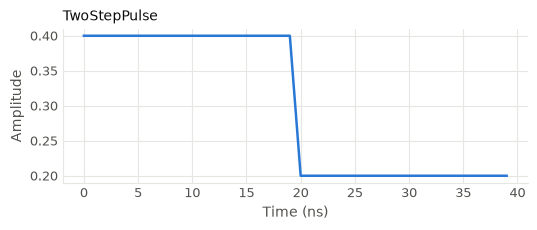

#!QProgram 0.2

require qdac 0.2

metadata:
  label: "exercise-3.1"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

fragment shaped_drive(drive, amplitude):
  play drive IQZero(envelope=TwoStepPulse(amplitude=amplitude, duration=40))

body:
  qdac.set_offset q[0].flux 0.05
  set_frequency q[0].drive 4850000000.0
  set_frequency q[0].readout 7200000000.0
  measure q[0].readout "probe" "weights" name="q0/readout/m0" fields=["state"]
  sync q[0].drive q[0].readout
  if q0/readout/m0.state == 1:
    shaped_drive(q[0].drive, 0.4)
  else:
    shaped_drive(q[0].drive, 0.2)

#!QProgram 0.2

require qdac 0.2

metadata:
  label: "exercise-3.1"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  qdac.set_offset q[0].flux 0.05
  set_frequency q[0].drive 4850000000.0
  set_frequency q[0].readout 7200000000.0
  measure q[0].readout "probe" "weights" name="q0/readout/m0" fields=["state"]
  sync q[0].drive q[0].r

In [59]:
import qprogram_qdac  # Register the QDAC namespace.
from qprogram.waveforms import IQZero


class TwoStepPulse(qp.waveforms.Waveform):
    """Use the requested amplitude for the first half, then half that amplitude."""

    def __init__(self, amplitude: float | qp.Expression, duration: int) -> None:
        self.amplitude = amplitude
        self.duration = duration

    def envelope(self, resolution: int = 1) -> np.ndarray:
        amplitude = self.amplitude
        if isinstance(amplitude, qp.Expression):
            amplitude = amplitude.evaluate_or_raise()

        sample_count = self.duration // resolution
        samples = np.full(sample_count, amplitude, dtype=float)
        samples[sample_count // 2:] *= 0.5  # Lower the second half of the pulse.
        return samples

    def get_duration(self) -> int:
        return self.duration


qp.register_waveform(TwoStepPulse)

TwoStepPulse(amplitude=0.4, duration=40).plot()
plt.show()


@qp.fragment
def shaped_drive(f, drive, amplitude):
    # The fragment parameter becomes the waveform's amplitude.
    pulse = TwoStepPulse(amplitude=amplitude, duration=40)
    f.play(drive, IQZero(pulse))


schema = BusSchema.flux_tunable_transmon()
q = schema.q

qprogram = qp.QProgram(label="exercise-3.1", schema=schema)
qprogram.qdac.set_offset(q[0].flux, 0.05)  # QDAC offsets are expressed in volts.
qprogram.set_frequency(q[0].drive, 4.85e9)
qprogram.set_frequency(q[0].readout, 7.20e9)

m_initial = qprogram.measure(
    q[0].readout, "probe", "weights", fields=(MeasurementField.STATE,)
)
qprogram.sync([q[0].drive, q[0].readout])  # The readout finishes before either drive pulse.

with qprogram.if_(m_initial.state == 1):
    qprogram.call(shaped_drive, q[0].drive, amplitude=0.4)
with qprogram.else_():
    qprogram.call(shaped_drive, q[0].drive, amplitude=0.2)

# The fragment is defined once and called with a different amplitude in each branch.
print(qp.dumps(qprogram))

# Expansion substitutes the arguments into each waveform.
qprogram = qprogram.expand()
print(qp.dumps(qprogram))

## Recap

- Define reusable sequences with `@qp.fragment`. The Python function runs at definition time, while fragment calls supply parameter values. Use `expand()` to inspect substituted operations and expand before binding waveform aliases inside fragments.
- Use conditionals to branch on a classified measurement state. Request `MeasurementField.STATE` and use a supported equality or inequality comparison. Skipped measurements contain `NaN`; combine branch arrays only when their missing-value patterns make that appropriate.
- Implement custom waveforms with `envelope()` and `get_duration()`. Resolve symbolic parameters when needed, then register serialisation support and a capability token. Custom sweep sources implement `length()` and `values()` and declare `KIND` and `TOKEN`.
- Package vendor operations with a namespace, operation classes, capability tokens, and a version. A `qprogram.vendors` entry point enables automatic loading from `.qp` requirements.
- Implement the six required platform members. Validate before execution, report diagnostics, and assemble measurements in a `QProgramResult`. The base class provides validation, planning, and explanation methods.
- Describe support through bus and platform profiles with real-time and host components. Use tokens, limits, and predicates to express requirements. Inspect plans with `qp.explain` and review changes in measurement order before applying `qp.optimize`.

## Where to go next

The [QProgram reference documentation](https://qilimanjaro-tech.github.io/qprogram) covers the API and extension interfaces in more detail. Its developer section is the next place to look when implementing a waveform, source, vendor extension, or platform.

You can also inspect `.qp` files from the command line:

- `python -m qprogram.lsp check file.qp` parses and validates a file, returning JSON.
- `python -m qprogram.lsp explain file.qp` displays its execution plan.
- `python -m qprogram.lsp serve` starts a Language Server Protocol service over standard input and output for editor integration.

The `qprogram-qblox` and `qprogram-qdac` packages provide further examples of vendor namespaces, operations, capability profiles, and predicates.